<a href="https://colab.research.google.com/github/Rodriguez-9819/Aaron_INFO4670_Fall2026/blob/main/Aaron_Rodriguez_INFO4670_Week3_Assignment1_Completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** Aaron Rodriguez    **Date:** September 6, 2026

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

## Setup — run this first (you don't need to change it)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data — run this, then look before you plot

In [6]:
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read from Google Drive — uncomment and edit the path:
# from google.colab import drive
# drive.mount("/content/drive")
# DATA_DIR = "/content/drive/MyDrive/.../Data"

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


In [7]:
# how many rows, which columns, what types?
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2027 non-null   object 
 1   major                 2027 non-null   object 
 2   age                   2027 non-null   int64  
 3   housing               2027 non-null   object 
 4   commute_miles         2027 non-null   float64
 5   work_hours_per_week   2027 non-null   int64  
 6   advisor_meetings      2027 non-null   int64  
 7   credits_attempted     2027 non-null   int64  
 8   final_gpa             2027 non-null   float64
 9   study_hours_reported  1772 non-null   float64
 10  enrollment_date       2027 non-null   object 
 11  dropped_out           2027 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 190.2+ KB


# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

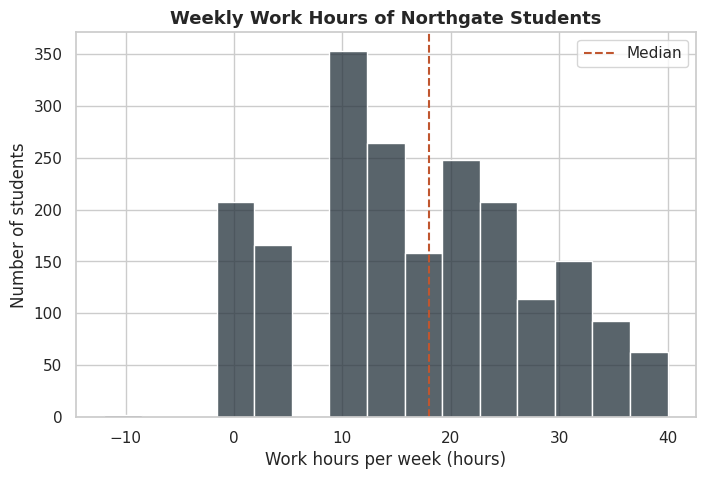

,work_hours_per_week
count,2027.000000
mean,17.284164
std,10.401333
min,-12.000000
25%,10.000000
50%,18.000000
75%,25.000000
max,40.000000


In [8]:
fig, ax = plt.subplots()
sns.histplot(data=students, x="work_hours_per_week", bins=15, color=NAVY, ax=ax)
ax.axvline(students["work_hours_per_week"].median(), color=RUST, linestyle="--", label="Median")
ax.set_title("Weekly Work Hours of Northgate Students")
ax.set_xlabel("Work hours per week (hours)")
ax.set_ylabel("Number of students")
ax.legend()
plt.show()

students["work_hours_per_week"].describe()

**STAR story — Q1**

This chart looks at `work_hours_per_week` for all 2,027 Northgate students and answers how much students typically work outside school. The median is 18 hours per week and the mean is about 17.3 hours, with the middle 50% of students falling between 10 and 25 hours. Most students are spread across a fairly wide range, but one value is especially concerning from a data-quality perspective: the minimum is -12 hours per week, which is not realistically possible. I would flag that record for review before using work hours in a later predictive model.

### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

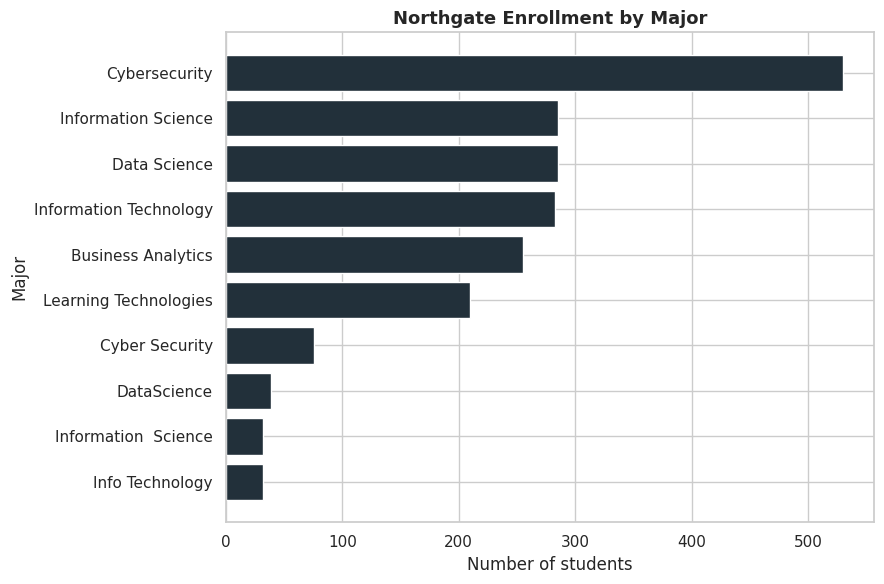

,count
major,
Info Technology,32
Information Science,32
DataScience,39
Cyber Security,76
Learning Technologies,210
Business Analytics,255
Information Technology,283
Data Science,285
Information Science,285


In [9]:
major_counts = students["major"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(major_counts.index, major_counts.values, color=NAVY)
ax.set_title("Northgate Enrollment by Major")
ax.set_xlabel("Number of students")
ax.set_ylabel("Major")
plt.tight_layout()
plt.show()

major_counts

**STAR story — Q2**

This chart compares enrollment across the `major` field for all Northgate students. Cybersecurity is the largest listed major with 530 students, while several other major labels have far fewer students. The chart also reveals a data-cleaning issue: labels such as `Cybersecurity` and `Cyber Security`, `Data Science` and `DataScience`, and multiple versions of Information Science and Information Technology appear to represent the same majors but are stored differently. Before making official enrollment comparisons, I would standardize those labels so each major is counted only once.

### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

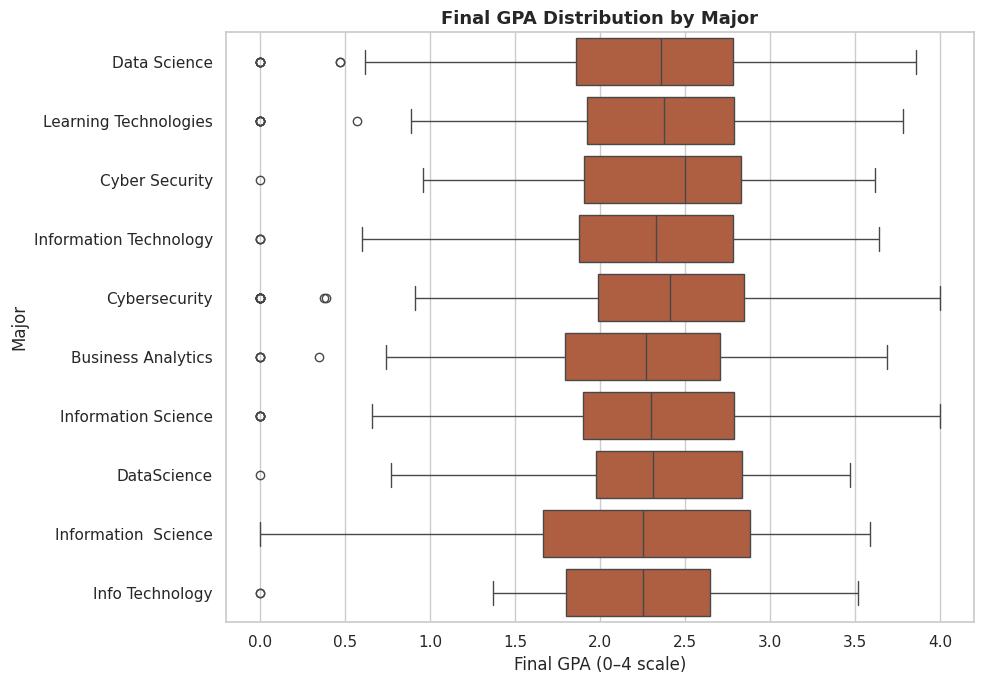

,final_gpa
major,
Information Science,2.255
Info Technology,2.255
Business Analytics,2.270
Information Science,2.300
DataScience,2.310
Information Technology,2.330
Data Science,2.360
Learning Technologies,2.375
Cybersecurity,2.410


In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.boxplot(data=students, x="final_gpa", y="major", color=RUST, ax=ax)
ax.set_title("Final GPA Distribution by Major")
ax.set_xlabel("Final GPA (0–4 scale)")
ax.set_ylabel("Major")
plt.tight_layout()
plt.show()

students.groupby("major")["final_gpa"].median().sort_values()

**STAR story — Q3**

This box plot compares `final_gpa` across the major categories in the student records. Median GPA values are fairly close overall, ranging from about 2.26 in the smaller Information Science and Info Technology labels to 2.50 in the `Cyber Security` label. The boxes overlap substantially, so the chart does not suggest a dramatic GPA separation by major. However, there are students at both very low and very high GPA values within several majors, and the duplicated major spellings make the comparison less reliable than it first appears. I would clean the major names first and then recheck whether any real major-level differences remain.

### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

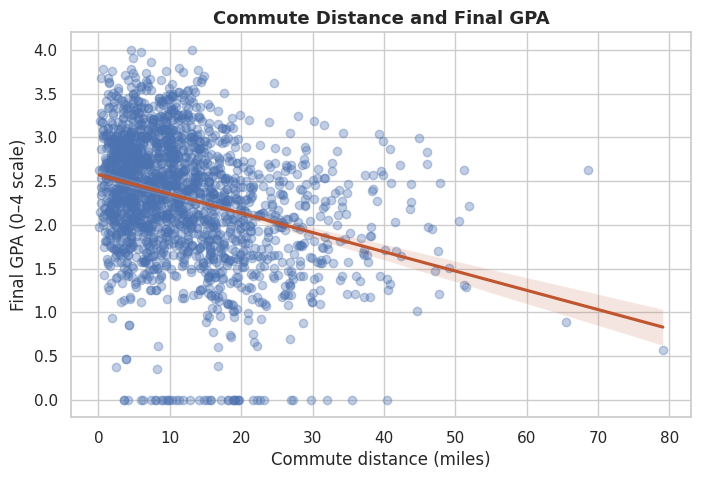

,commute_miles,final_gpa
commute_miles,1.000000,-0.295108
final_gpa,-0.295108,1.000000


In [11]:
fig, ax = plt.subplots()
sns.regplot(
    data=students,
    x="commute_miles",
    y="final_gpa",
    scatter_kws={"alpha": 0.35},
    line_kws={"color": RUST},
    ax=ax
)
ax.set_title("Commute Distance and Final GPA")
ax.set_xlabel("Commute distance (miles)")
ax.set_ylabel("Final GPA (0–4 scale)")
plt.show()

students[["commute_miles", "final_gpa"]].corr()

**STAR story — Q4**

This scatterplot compares each student's `commute_miles` with `final_gpa` and uses a fitted trend line to show the overall association. The relationship is negative, with a correlation of about -0.30, meaning students with longer commutes tend to have somewhat lower GPAs on average. The points are still widely scattered, so commute distance alone does not explain GPA very well and the chart does not establish causation. I would next compare commute distance with other factors such as work hours, housing, or weekly engagement to see whether they help explain the pattern.

### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

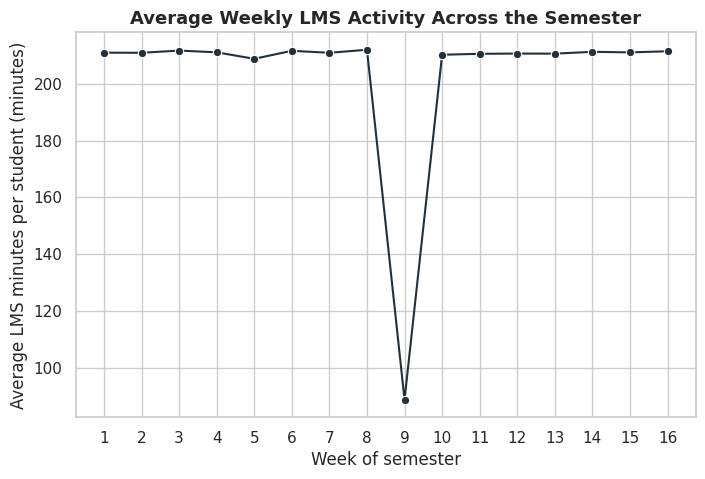

,week,minutes_active
0,1,210.9805
1,2,210.9365
2,3,211.7105
3,4,211.1095
4,5,208.8125
5,6,211.6380
6,7,210.9370
7,8,212.0085
8,9,88.6370
9,10,210.2460


In [12]:
weekly_avg = weekly.groupby("week", as_index=False)["minutes_active"].mean()

fig, ax = plt.subplots()
sns.lineplot(data=weekly_avg, x="week", y="minutes_active", marker="o", color=NAVY, ax=ax)
ax.set_title("Average Weekly LMS Activity Across the Semester")
ax.set_xlabel("Week of semester")
ax.set_ylabel("Average LMS minutes per student (minutes)")
ax.set_xticks(weekly_avg["week"])
plt.show()

weekly_avg

**STAR story — Q5**

This line chart tracks the average `minutes_active` in the LMS for each week of the semester. Engagement is remarkably steady at about 209–212 minutes per week for most of the 16 weeks. Week 9 is the major exception, dropping sharply to about 88.6 average minutes before immediately returning to the previous level in week 10. Because the drop is isolated to one week rather than part of a continuing decline, I would investigate whether week 9 was a break, shortened instructional week, system issue, or unusual event before interpreting it as widespread student disengagement.

# Part B — Your own question

**Question:** Do students who eventually drop out show a different final GPA distribution from students who remain enrolled?

A violin plot is useful here because it shows both the center and the full shape of the GPA distribution for the two groups.

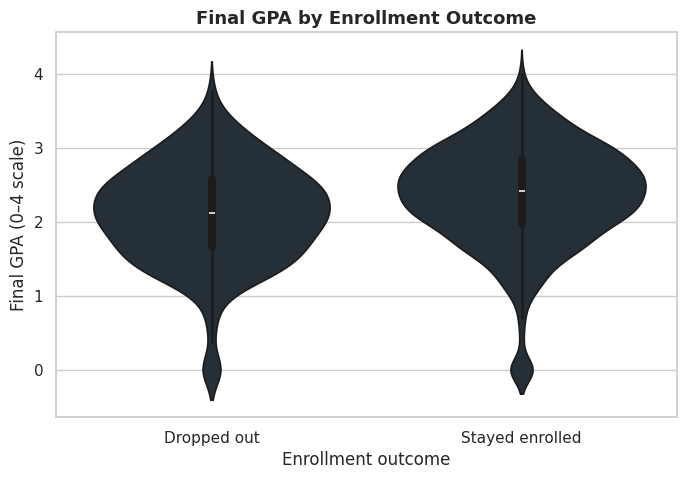

,count,mean,median
dropped_out,,,
0,1600,2.361213,2.415
1,427,2.106112,2.120


In [13]:
plot_data = students.copy()
plot_data["Enrollment outcome"] = plot_data["dropped_out"].map({0: "Stayed enrolled", 1: "Dropped out"})

fig, ax = plt.subplots()
sns.violinplot(
    data=plot_data,
    x="Enrollment outcome",
    y="final_gpa",
    inner="box",
    color=NAVY,
    ax=ax
)
ax.set_title("Final GPA by Enrollment Outcome")
ax.set_xlabel("Enrollment outcome")
ax.set_ylabel("Final GPA (0–4 scale)")
plt.show()

students.groupby("dropped_out")["final_gpa"].agg(["count", "mean", "median"])

**STAR story — Part B**

This chart compares the distribution of `final_gpa` for students who stayed enrolled with students marked as having dropped out. Students who remained enrolled had an average GPA of about 2.36 and a median of about 2.42, while students who dropped out had a lower average of about 2.11 and a median of about 2.12. The distributions still overlap, so GPA by itself cannot identify every student who will drop out, but the lower center among the dropout group suggests that academic performance may be one useful early-warning signal. I would next combine GPA with earlier measures such as LMS activity, work hours, and commute distance to look for students showing several risk indicators at the same time.

# Before you submit — checklist
- [ ] The notebook **runs top to bottom** with no errors (Runtime → Restart and run all).
- [ ] All **6 charts** are present, each with a title, labeled axes, and units/legend where needed.
- [ ] Each chart has a **complete STAR story**, including any exceptions you spotted.
- [ ] Part B question is written in and answered.
- [ ] Pushed to **GitHub**, and the **GitHub link** is submitted in Canvas.

**Rubric (70 pts):** chart choice 10 · correct build 20 · labeling 10 · STAR reading 18 · Part B question 4 · submission & professionalism 8.